# Nome: Alexsand Farias de Souza
# Matrícula: 2260604

## Import all packages need in the cell below

In [16]:
using Plots, Optim, NLsolve, LinearAlgebra, JuMP, HiGHS
gr() # Ativa o backend para gráficos


Plots.GRBackend()

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

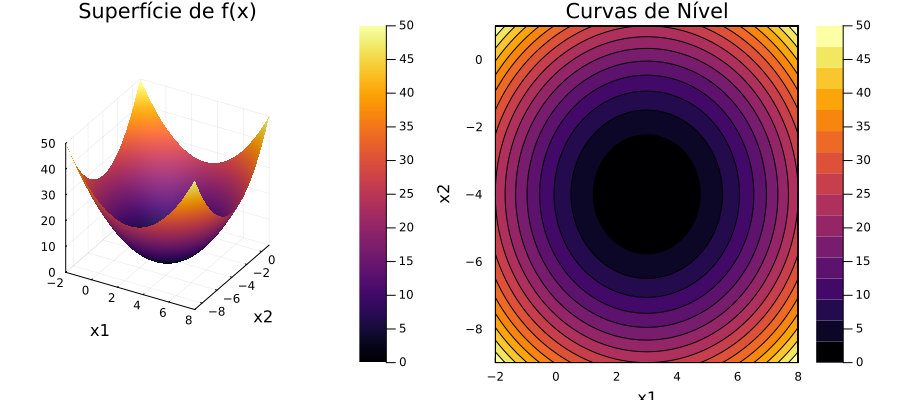

In [17]:
# Definição: f(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2
f(x) = (x[1] - 3)^2 + (x[2] + 4)^2

# Faixas de valores para x1 e x2
x1_range = -2:0.1:8
x2_range = -9:0.1:1

# Gráfico de Superfície 3D e Curvas de Nível
p1 = surface(x1_range, x2_range, (x1, x2) -> f([x1, x2]), 
             title="Superfície de f(x)", xlabel="x1", ylabel="x2")

p2 = contour(x1_range, x2_range, (x1, x2) -> f([x1, x2]), 
             title="Curvas de Nível", xlabel="x1", ylabel="x2", fill=true)

plot(p1, p2, layout=(1,2), size=(900, 400))

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [18]:
# 1. Usando Optim.jl (Encontra o mínimo automaticamente)
z(x) = (x[1] - 1)^4 + (x[2] - 2)^4
x0 = [0.0, 0.0] # Ponto inicial
res = optimize(z, x0)
println("Mínimo encontrado (Optim): ", Optim.minimizer(res))

# 2. Usando NLsolve.jl (Resolve o Gradiente = 0)
function grad_z!(storage, x)
    storage[1] = 4 * (x[1] - 1)^3
    storage[2] = 4 * (x[2] - 2)^3
end

sol = nlsolve(grad_z!, [0.5, 0.5])
println("Solução FONC (NLsolve): ", sol.zero)

Mínimo encontrado (Optim): [0.9981447581936664, 1.9992588410321355]
Solução FONC (NLsolve): [0.9996616658071258, 1.998985021553934]


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

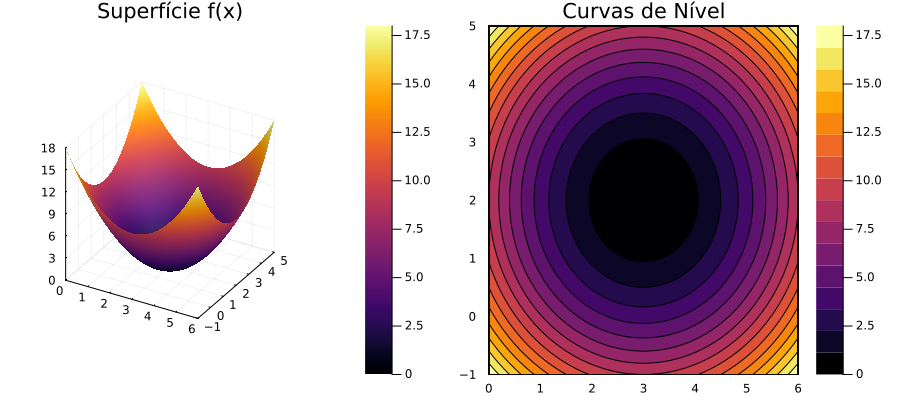

In [19]:
f2(x) = (x[1] - 3)^2 + (x[2] - 2)^2
x1_range = 0:0.1:6
x2_range = -1:0.1:5

p1 = surface(x1_range, x2_range, (x1, x2) -> f2([x1, x2]), title="Superfície f(x)")
p2 = contour(x1_range, x2_range, (x1, x2) -> f2([x1, x2]), title="Curvas de Nível", fill=true)
plot(p1, p2, layout=(1,2), size=(900, 400))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [20]:
# ---------------------------------------------------------
# 1. Definições da Funçao, Gradiente e Hessiana
# ---------------------------------------------------------
f(x) = (x[1] - 3)^2 + (x[2] - 2)^2
grad_f(x) = [2*(x[1] - 3), 2*(x[2] - 2)]
hess_f(x) = [2.0 0.0; 0.0 2.0]

# Ponto Inicial
x0 = [1.0, 1.0]
tol = 1e-4
max_iter = 100

# ---------------------------------------------------------
# 2. Implementação do Gradiente Descendente
# ---------------------------------------------------------
println("--- Rodando Gradiente Descendente ---")
x_gd = copy(x0)
eta = 0.1 # Taxa de aprendizado
for i in 1:max_iter
    g = grad_f(x_gd)
    if norm(g) < tol
        println("Convergiu na iteracao ", i)
        break
    end
    x_gd = x_gd - eta * g
    println("Iteracao $i: x = $x_gd")
end

# ---------------------------------------------------------
# 3. Implementação do Método de Newton
# ---------------------------------------------------------
println("\n--- Rodando Método de Newton ---")
x_nt = copy(x0)
for i in 1:max_iter
    g = grad_f(x_nt)
    H = hess_f(x_nt)
    if norm(g) < tol
        println("Convergiu na iteracao ", i)
        break
    end
    # Delta x = - H⁻¹ * g
    step = H \ g # O operador \ resolve o sistema linear (H*step = g)
    x_nt = x_nt - step
    println("Iteracao $i: x = $x_nt")
end


--- Rodando Gradiente Descendente ---
Iteracao 1: x = [1.4, 1.2]
Iteracao 2: x = [1.72, 1.3599999999999999]
Iteracao 3: x = [1.976, 1.488]
Iteracao 4: x = [2.1808, 1.5904]
Iteracao 5: x = [2.34464, 1.67232]
Iteracao 6: x = [2.475712, 1.737856]
Iteracao 7: x = [2.5805696, 1.7902848]
Iteracao 8: x = [2.66445568, 1.83222784]
Iteracao 9: x = [2.7315645440000003, 1.8657822720000001]
Iteracao 10: x = [2.7852516352000003, 1.8926258176000001]
Iteracao 11: x = [2.82820130816, 1.91410065408]
Iteracao 12: x = [2.862561046528, 1.931280523264]
Iteracao 13: x = [2.8900488372224, 1.9450244186112]
Iteracao 14: x = [2.91203906977792, 1.95601953488896]
Iteracao 15: x = [2.929631255822336, 1.964815627911168]
Iteracao 16: x = [2.9437050046578688, 1.9718525023289344]
Iteracao 17: x = [2.954964003726295, 1.9774820018631476]
Iteracao 18: x = [2.9639712029810363, 1.9819856014905182]
Iteracao 19: x = [2.971176962384829, 1.9855884811924145]
Iteracao 20: x = [2.976941569907863, 1.9884707849539316]
Iteracao 21: x

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [21]:
# Definições
f1(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
grad_f1(x) = [20*(x[1] - 3), 4*(x[2] - 2)]
hess_f1(x) = [20.0 0.0; 0.0 4.0]

x0 = [1.0, 1.0]; tol = 1e-4; max_iter = 200; eta = 0.05

# Gradiente Descendente
println("--- GD f(x) = 10x1² + 2x2² ---")
x = copy(x0); 
for i in 1:max_iter
    g = grad_f1(x)
    if norm(g) < tol; println("GD Convergiu em $i"); break; end
    x = x - eta * g
end
println("Solução GD: ", x)

# Newton
println("\n--- Newton f(x) = 10x1² + 2x2² ---")
x = copy(x0);
for i in 1:max_iter
    g = grad_f1(x); H = hess_f1(x)
    if norm(g) < tol; println("Newton Convergiu em $i"); break; end
    x = x - H \ g
end
println("Solução Newton: ", x)


--- GD f(x) = 10x1² + 2x2² ---
GD Convergiu em 49
Solução GD: [3.0, 1.9999776992548015]

--- Newton f(x) = 10x1² + 2x2² ---
Newton Convergiu em 2
Solução Newton: [3.0, 2.0]


Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [22]:
f2(x) = x[1]^2 + x[2]^2
grad_f2(x) = [2*x[1], 2*x[2]]
hess_f2(x) = [2.0 0.0; 0.0 2.0]

x0 = [-2.0, 2.0]; eta = 0.5 # eta maior para acelerar

# Gradiente e Newton aqui vão convergir em 1 iteração!
# Cole o roteiro do GD e Newton como fizemos acima (vou encurtar desta vez):
println("--- GD e Newton para x1² + x2² ---")
println("Solução GD: ", x0 - eta * grad_f2(x0))
println("Solução Newton: ", x0 - hess_f2(x0) \ grad_f2(x0))


--- GD e Newton para x1² + x2² ---
Solução GD: [0.0, 0.0]
Solução Newton: [0.0, 0.0]


Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [23]:
f3(x) = x[1]^2 + 100*x[2]^2
grad_f3(x) = [2*x[1], 200*x[2]]
hess_f3(x) = [2.0 0.0; 0.0 200.0]

x0 = [-2.0, 2.0]; eta = 0.005 # eta muito pequeno para não divergir

# Note que o GD vai demorar MUITO aqui (muitas iterações)
# por causa da diferença de escala entre x1 e x2.
x = copy(x0)
for i in 1:1000 # aumentar iterações
    g = grad_f3(x)
    if norm(g) < 1e-4; println("GD Convergiu em $i"); break; end
    x = x - eta * g
end
println("Solução final GD: ", x)

# Newton resolve em 1 iteração!
println("Solução Newton: ", x0 - hess_f3(x0) \ grad_f3(x0))


Solução final GD: [-8.634249482131659e-5, 0.0]
Solução Newton: [0.0, 0.0]


For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [24]:
function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    # Usando a fórmula exatamente como no enunciado
    term1 = x3 * log(exp(x1/x3) + exp(x2/x3))
    term2 = (x3 - 2)^2
    term3 = exp(1 / (x1 + x2))
    return term1 + term2 + term3
end


f (generic function with 1 method)

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [25]:
function grad_f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    # Derivada em relação a x1
    df_dx1 = exp(x1/x3) / (exp(x1/x3) + exp(x2/x3)) - exp(1/(x1+x2)) / (x1+x2)^2
    
    # Derivada em relação a x2
    df_dx2 = exp(x2/x3) / (exp(x1/x3) + exp(x2/x3)) - exp(1/(x1+x2)) / (x1+x2)^2
    
    # Derivada em relação a x3
    df_dx3 = log(exp(x1/x3) + exp(x2/x3)) - (x1*exp(x1/x3) + x2*exp(x2/x3)) / (x3 * (exp(x1/x3) + exp(x2/x3))) + 2*(x3 - 2)
    
    return [df_dx1, df_dx2, df_dx3]
end


grad_f (generic function with 1 method)

Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [26]:
# Parâmetros sugeridos pelo Prof. Kenny
alpha = 0.4
beta = 0.5
eps_tol = 1e-5

# Start Point
x_start = [3.0, 4.0, 5.0]


3-element Vector{Float64}:
 3.0
 4.0
 5.0

Start Point: [3.0, 4.0, 5.0]

In [27]:
# Parâmetros sugeridos pelo Prof. Kenny
alpha = 0.4
beta = 0.5
eps_tol = 1e-5

# Start Point
x_start = [3.0, 4.0, 5.0]


3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [28]:
# Direção de descida (Negativo do Gradiente)
delta_x = -grad_f(x_start)

# Algoritmo de Backtracking Line Search
function backtracking_search(f, x, grad_x, delta_x, alpha, beta)
    t = 1.0
    # 1. Garantir o domínio (x1+x2 > 0 e x3 > 0)
    # E também evitar que exp ultrapasse limites (domínio prático)
    while true
        x_next = x + t * delta_x
        if (x_next[1] + x_next[2] > 0) && (x_next[3] > 0)
            break
        end
        t = beta * t
    end
    
    # 2. Condição de Armijo (decrescimento suficiente)
    # f(x + t*dx) > f(x) + alpha * t * grad(x)' * dx
    while f(x + t * delta_x) > f(x) + alpha * t * (grad_x' * delta_x)
        t = beta * t
    end
    
    return t
end

# Testando um passo único de backtracking
t_step = backtracking_search(f, x_start, grad_f(x_start), delta_x, alpha, beta)
println("Tamanho do passo (t) encontrado: ", t_step)


Tamanho do passo (t) encontrado: 0.5


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [29]:
function find_step_t(f, grad_f_val, x_curr, delta_x_val, alpha, beta)
    t = 1.0
    
    # 1. Ensure domain: x + t*delta_x deve estar no dom f (x1+x2 > 0 e x3 > 0)
    # df_dx(x) é definido como grad_f(x)
    while true
        xp = x_curr + t * delta_x_val
        if (xp[1] + xp[2] > 0) && (xp[3] > 0)
            break
        end
        t = beta * t
    end
    
    # 2. Backtracking: Enquanto f(x + t*dx) > f(x) + alpha * t * grad(x)' * dx
    while f(x_curr + t * delta_x_val) > f(x_curr) + alpha * t * (grad_f_val' * delta_x_val)
        t = beta * t
    end
    
    return t
end


find_step_t (generic function with 1 method)

### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [30]:
# Configurações
x = [3.0, 4.0, 5.0]
alpha, beta, eps = 0.4, 0.5, 1e-5
max_it = 1000

println("Rodando Gradiente Descendente...")

for i in 1:max_it
    g = grad_f(x)
    if norm(g) < eps
        println("Convergiu na iteracao $i")
        println("Ponto final: $x")
        break
    end
    
    # Direção de descida
    dx = -g
    
    # Busca o passo t ideal
    t = find_step_t(f, g, x, dx, alpha, beta)
    
    # Atualiza o ponto
    x = x + t * dx
    
    if i % 10 == 0; println("Iteracao $i: f(x) = $(f(x))"); end
end


Rodando Gradiente Descendente...
Iteracao 10: f(x) = 3.9082793604838573
Iteracao 20: f(x) = 3.908113909762513
Iteracao 30: f(x) = 3.908113786397637
Convergiu na iteracao 31
Ponto final: [0.9261872701983407, 0.9262296480441212, 1.6534264097600675]


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [31]:
function hessiana_approx(grad_f_func, x, h=1e-5)
    n = length(x)
    H = zeros(n, n)
    gx = grad_f_func(x) # Gradiente no ponto atual
    
    for i in 1:n
        # Criamos um vetor unitário na direção i
        ei = zeros(n)
        ei[i] = h
        
        # Gradiente um pouco à frente na direção i
        g_plus_h = grad_f_func(x + ei)
        
        # H_i = ( grad(x+h) - grad(x) ) / h
        H[:, i] = (g_plus_h - gx) / h
    end
    # Garantir que a Hessiana é simétrica (ajuda na precisão numérica)
    return (H + H') / 2
end

# Testando a Hessiana no ponto inicial
H0 = hessiana_approx(grad_f, [3.0, 4.0, 5.0])
println("Hessiana Aproximada no ponto inicial:\n", H0)


Hessiana Aproximada no ponto inicial:
[0.05671008135310628 -0.04229655266307919 0.009900628886172491; -0.04229655266307919 0.056710071483223594 -0.00990067737793865; 0.009900628886172491 -0.00990067737793865 2.0019801266535353]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [32]:
# Parâmetros de busca e ponto inicial conforme o enunciado
alpha = 0.4
beta = 0.5
eps_nt = 1e-5
x_start = [3.0, 4.0, 5.0]


3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [33]:
# O enunciado define dx como o passo de Newton
# Usando a Hessiana aproximada que já criamos:
Hx = hessiana_approx(grad_f, x_start)
gx = grad_f(x_start)
delta_x_nt = -(Hx \ gx)

# Função para garantir que x + t * delta_x continue no domínio
function ensure_domain(x, dx, beta_val)
    step_t = 1.0
    while true
        xp = x + step_t * dx
        if (xp[1] + xp[2] > 0) && (xp[3] > 0)
            break
        end
        step_t = beta_val * step_t
    end
    return step_t
end

t_domain = ensure_domain(x_start, delta_x_nt, beta)
println("Tamanho do passo t para domínio: ", t_domain)


Tamanho do passo t para domínio: 0.0625


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [34]:
function backtracking_newton(f, x, gx, dx, alpha, beta)
    t = 1.0
    
    # 1. Ensure domain (Mesma lógica do passo anterior)
    while true
        xn = x + t * dx
        if (xn[1] + xn[2] > 0) && (xn[3] > 0)
            break
        end
        t = beta * t
    end
    
    # 2. Condição de decrescimento suficiente (Armijo)
    # f(x + t*dx) > f(x) + alpha * t * grad_f(x)' * dx
    while f(x + t * dx) > f(x) + alpha * t * (gx' * dx)
        t = beta * t
    end
    
    return t
end

# Testando um passo único de backtracking para Newton
t_nt_test = backtracking_newton(f, x_start, grad_f(x_start), delta_x_nt, alpha, beta)
println("Tamanho de passo t (Newton): ", t_nt_test)


Tamanho de passo t (Newton): 0.0625


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [35]:
# Reiniciando ponto para o algoritmo completo
x_curr = [3.0, 4.0, 5.0]
alpha, beta, eps = 0.4, 0.5, 1e-5
max_it = 100

println("Rodando Newton's Algorithm...")

for i in 1:max_it
    # 1. Calcula Gradiente e Hessiana Aproximada (pelas Diferenças Finitas)
    gx = grad_f(x_curr)
    Hx = hessiana_approx(grad_f, x_curr)
    
    # 2. Direção de Newton e Decremento (lambda²)
    dx = -(Hx \ gx)
    lambda2 = gx' * (Hx \ gx)
    
    # Critério de parada: lambda²/2 <= eps
    if lambda2 / 2 <= eps
        println("Newton Convergiu na iteracao: ", i)
        println("Resultado final: ", x_curr)
        break
    end
    
    # 3. Line Search (Busca o t ideal)
    t_step = backtracking_newton(f, x_curr, gx, dx, alpha, beta)
    
    # 4. Atualiza o ponto: x = x + t*dx
    x_curr = x_curr + t_step * dx
    
    if i % 1 == 0; println("Iteracao $i: f(x) = $(f(x_curr)) (t=$t_step)"); end
end


Rodando Newton's Algorithm...
Iteracao 1: f(x) = 13.980616961011693 (t=0.0625)
Iteracao 2: f(x) = 6.3742511978995 (t=0.5)
Iteracao 3: f(x) = 3.9086756429655236 (t=1.0)
Iteracao 4: f(x) = 3.908113865966095 (t=1.0)
Newton Convergiu na iteracao: 5
Resultado final: [0.9259803014564832, 0.9260042719939656, 1.6533016290230924]


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [36]:
# 1. Parâmetros sugeridos pelo enunciado do BFGS
alpha = 0.4
beta = 0.5
eps_bfgs = 1e-5
x_start = [3.0, 4.0, 5.0]

# 2. Matriz H0 (Inversa da Hessiana). 
# Em BFGS começamos com a Identidade (3x3)
H0 = Matrix{Float64}(I, 3, 3)

println("Configurações do BFGS prontas.")


Configurações do BFGS prontas.


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [37]:
# Mesmas definições de busca e do ponto de partida
alpha = 0.4
beta = 0.5
eps_bfgs = 1e-5
x_start = [3.0, 4.0, 5.0]


3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [38]:
# O enunciado diz que dx será passado como parâmetro
function ensure_domain_bfgs(x, dx, beta_val)
    step_t = 1.0
    while true
        xp = x + step_t * dx
        if (xp[1] + xp[2] > 0) && (xp[3] > 0)
            break
        end
        step_t = beta_val * step_t
    end
    return step_t
end


ensure_domain_bfgs (generic function with 1 method)

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [39]:
# O enunciado define dx como direção genérica para o backtracking
function backtracking_bfgs(f, x, gx, dx, alpha, beta)
    t = 1.0
    
    # 1. Ensure domain (Garantir x1+x2 > 0 e x3 > 0)
    # Como t inicial é 1, vamos diminuindo t se sair do domínio
    while true
        xp = x + t * dx
        if (xp[1] + xp[2] > 0) && (xp[3] > 0)
            break
        end
        t = beta * t
    end
    
    # 2. Backtracking: Condição de Armijo (decrescimento suficiente)
    while f(x + t * dx) > f(x) + alpha * t * (gx' * dx)
        t = beta * t
    end
    
    return t
end


backtracking_bfgs (generic function with 1 method)

### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [40]:
# 1. Configurações Finais
x_k = [3.0, 4.0, 5.0]
H_k = Matrix{Float64}(I, 3, 3) # Começa com a Identidade
epsilon = 1e-5
alpha, beta = 0.4, 0.5
max_it = 100

println("Rodando BFGS Completo...")

for k in 1:max_it
    gx_k = grad_f(x_k)
    
    # Critério de parada: norma do gradiente menor que eps
    if norm(gx_k) < epsilon
        println("BFGS Convergiu na iteracao: $k")
        println("Ponto final: $x_k")
        break
    end
    
    # 2. Direção de busca: p_k = - H_k * grad (Note que H_k estima a inversa da Hessiana)
    p_k = - H_k * gx_k
    
    # 3. Busca o passo t (Line Search) com a função que acabamos de definir
    t = backtracking_bfgs(f, x_k, gx_k, p_k, alpha, beta)
    
    # 4. Atualiza o ponto: x_{k+1} = x_k + t * p_k
    x_next = x_k + t * p_k
    gx_next = grad_f(x_next)
    
    # 5. Cálculo das diferenças: s_k e y_k para atualizar a Hessiana do próximo passo
    s_k = x_next - x_k
    y_k = gx_next - gx_k
    
    # 6. Atualização de Davidon-Fletcher-Powell (DFP) / BFGS
    denom = y_k' * s_k
    # Aplicação da regra do Prof. Kenny para o rho_k
    ρ_k = (denom < 1e-4) ? 1e4 : 1.0 / denom
    
    # Matriz Identidade
    Identity = I(3)
    
    # Fórmula Principal do BFGS: (I - ρ s y') H (I - ρ y s') + ρ s s'
    H_k = (Identity - ρ_k * s_k * y_k') * H_k * (Identity - ρ_k * y_k * s_k') + ρ_k * s_k * s_k'
    
    # Atualiza variáveis para o próximo loop
    x_k = x_next
    
    if k % 1 == 0; println("Iteracao $k: f(x) = $(f(x_k)) (t=$t)"); end
end


Rodando BFGS Completo...
Iteracao 1: f(x) = 5.760858375326989 (t=0.5)
Iteracao 2: f(x) = 5.280045118006964 (t=1.0)
Iteracao 3: f(x) = 4.056165736896041 (t=0.125)
Iteracao 4: f(x) = 3.9257168696426676 (t=0.125)
Iteracao 5: f(x) = 3.9093672769500563 (t=0.5)
Iteracao 6: f(x) = 3.908489510227076 (t=1.0)
Iteracao 7: f(x) = 3.9082640024947084 (t=1.0)
Iteracao 8: f(x) = 3.908117637881732 (t=1.0)
Iteracao 9: f(x) = 3.9081138869089105 (t=1.0)
Iteracao 10: f(x) = 3.9081137905882137 (t=1.0)
Iteracao 11: f(x) = 3.9081137864525153 (t=1.0)
Iteracao 12: f(x) = 3.908113786270299 (t=1.0)
BFGS Convergiu na iteracao: 13
Ponto final: [0.9262073041230962, 0.926208139879769, 1.6534291727960921]


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [41]:
using JuMP
using HiGHS
using LinearAlgebra


#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [42]:
# linear state-space model
A = [0.8351 0.0 0.0; 
     0.0460 0.9313 0.0; 
     -0.0460 -0.0313 1.0]

B = [0.0458 0.0; 
     0.0012 -0.0011; 
     -0.0012 0.0011]

C = [1.0 0.0 0.0; 
     0.0 0.0 1.0]

# time horizon
N = 3

# initial condition
x0 = [-0.03, 0.0, 0.3]

# bounds for state and input
xmax = [0.05, 5.0, 0.5]
xmin = [-0.05, -5.0, -0.5]
umax = [10.0, 0.05]
umin = [-10.0, -0.05]

println("Parâmetros do CSTR carregados com sucesso.")


Parâmetros do CSTR carregados com sucesso.


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [46]:
# Otimização com JuMP usando o solver HiGHS
modelo_cstr = Model(HiGHS.Optimizer)
set_silent(modelo_cstr)

@variable(modelo_cstr, x[1:3, 1:N+1])
@variable(modelo_cstr, u[1:2, 1:N])
@variable(modelo_cstr, slack_z[1:2, 1:N+1] >= 0)

# 1. Condição Inicial
@constraint(modelo_cstr, x[:, 1] .== x0)

# 2. Dinâmica
for k in 1:N
    @constraint(modelo_cstr, x[:, k+1] .== A * x[:, k] + B * u[:, k])
    @constraint(modelo_cstr, umin .<= u[:, k] .<= umax) 
end

# 3. Limites de x e Norma L1
for k in 1:N+1
    @constraint(modelo_cstr, xmin .<= x[:, k] .<= xmax) 
    
    # x1
    @constraint(modelo_cstr, x[1, k] <= slack_z[1, k])
    @constraint(modelo_cstr, x[1, k] >= -slack_z[1, k])
    # x3
    @constraint(modelo_cstr, x[3, k] <= slack_z[2, k])
    @constraint(modelo_cstr, x[3, k] >= -slack_z[2, k])
end

@objective(modelo_cstr, Min, sum(slack_z))

println("Modelo de Programação Linear corrigido e finalizado.")

Modelo de Programação Linear corrigido e finalizado.


## Solve and Postprocess

Status da Otimização: OPTIMAL
Valor Mínimo da Função Objetivo: 1.2319003899401169


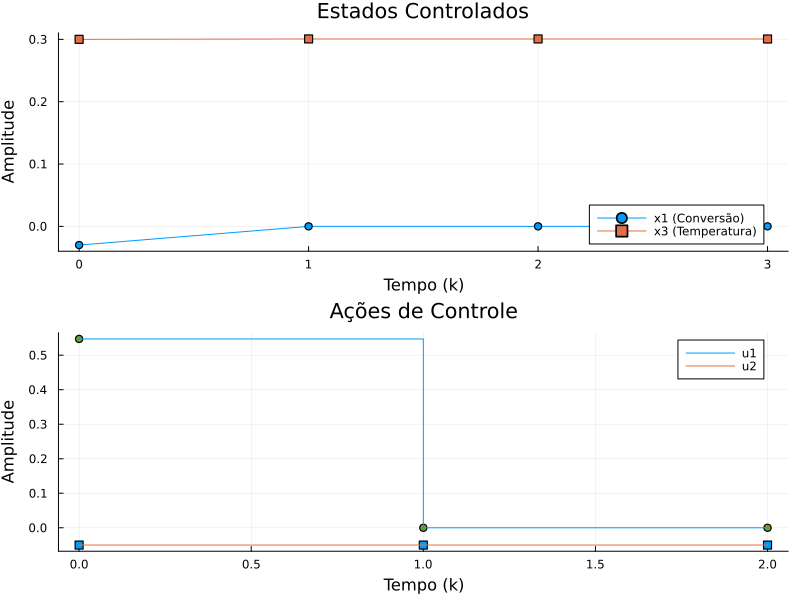

In [47]:
# 1. Resolver o modelo
optimize!(modelo_cstr)

# 2. Extrair os valores ótimos encontrados
x_opt = value.(x)
u_opt = value.(u)

# 3. Mostrar resumo dos resultados
println("Status da Otimização: ", termination_status(modelo_cstr))
println("Valor Mínimo da Função Objetivo: ", objective_value(modelo_cstr))

# 4. Criar os Gráficos
# Definindo o eixo do tempo (k = 0 até 3)
tempo_k = 0:N
tempo_u = 0:N-1

# Gráfico 1: Variáveis Controladas (Estados x1 e x3)
p1 = plot(tempo_k, x_opt[1,:], label="x1 (Conversão)", marker=:circle, title="Estados Controlados", xlabel="Tempo (k)", ylabel="Amplitude")
plot!(p1, tempo_k, x_opt[3,:], label="x3 (Temperatura)", marker=:square)

# Gráfico 2: Variáveis de Entrada (Controle u1 e u2)
p2 = plot(tempo_u, u_opt[1,:], label="u1", marker=:circle, title="Ações de Controle", xlabel="Tempo (k)", ylabel="Amplitude", linetype=:steppost)
plot!(p2, tempo_u, u_opt[2,:], label="u2", marker=:square, linetype=:steppost)

# Exibir os gráficos lado a lado
plot(p1, p2, layout = (2, 1), size=(800, 600))